In [ ]:
import numpy as np
# from PIL import Image
import taichi as ti
# import taichi_volume_renderer as tvr
import matplotlib.pyplot as plt

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


# 用单个文件测试网格转化

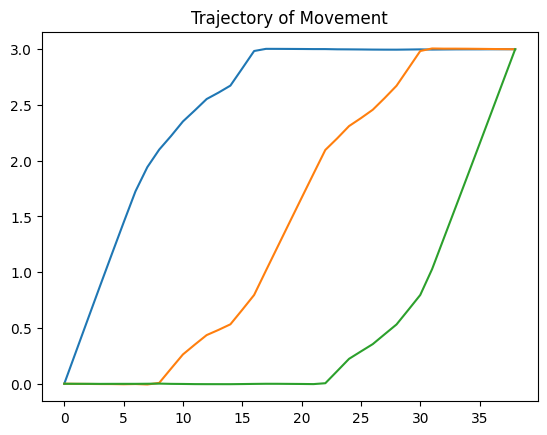

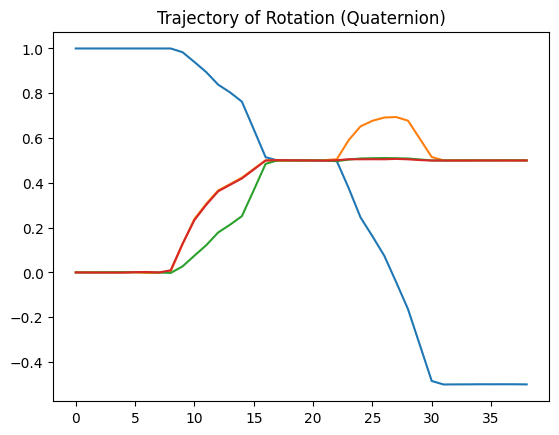

In [ ]:
sofa_w = 3.5  # 求解域的尺寸
sofa_h = 1
sofa_d = 1

# @ti.func
# def is_forbidden_1(x0, y0, z0, x1, y1, z1):  # 指定哪里是墙（两个正方形孔）
#     return ((x0 > 0.) ^ (x1 > 0.)) and (((y1 > 0.) ^ (z1 > 0.)) or abs(y1) > 0.5 or abs(z1) > 0.5)  # 两个正方形的孔

# @ti.func
# def is_forbidden_2(x0, y0, z0, x1, y1, z1):  # 指定哪里是墙（两个正方形孔）（有厚度的墙，有厚度是为了避免展示视频中出现明显的穿模）
#     return (((x0 > 0.) ^ (x1 > 0.)) or abs(x1) < 0.01) and (((y1 > 0.) ^ (z1 > 0.)) or abs(y1) > 0.5 or abs(z1) > 0.5)  # 两个正方形的孔

segment_length = 3  # 单段走廊的长度，在足够大的情况下，修改这个值不会影响沙发形状
@ti.func
def is_forbidden(x1, y1, z1):  # 指定哪里是墙（两个直角拐弯）
    return not ((abs(y1) <= 0.5 and abs(z1) <= 0.5 and x1 <= segment_length + 0.5) or (abs(x1 - segment_length) <= 0.5 and abs(z1) <= 0.5 and y1 >= -0.5 and y1 <= segment_length + 0.5) or (abs(x1 - segment_length) <= 0.5 and abs(y1 - segment_length) <= 0.5 and z1 >= -0.5))  # 三段走廊

trajectory = np.load('../trajectory/两个直角拐弯_c型旋转_2/sofa_5000.npy')
xs = trajectory[:, 0]
ys = trajectory[:, 1]
zs = trajectory[:, 2]
rotations = trajectory[:, 3:]

len(xs)

plt.plot(xs, markersize=2)
plt.plot(ys, markersize=2)
plt.plot(zs, markersize=2)
plt.title('Trajectory of Movement')
plt.show()

plt.plot(rotations[:, 0], markersize=2)
plt.plot(rotations[:, 1], markersize=2)
plt.plot(rotations[:, 2], markersize=2)
plt.plot(rotations[:, 3], markersize=2)
plt.title('Trajectory of Rotation (Quaternion)')
plt.show()


In [5]:
from utils import get_sofa_3d

sofa = get_sofa_3d(is_forbidden, xs, ys, zs, rotations, sofa_w=sofa_w, sofa_h=sofa_h, sofa_d=sofa_d, resolution=1024, trajectory_upsampling=201)

sofa.shape

(1024, 292, 292)

In [6]:
from tooppy.mesh import convert_to_mesh, plot_mesh, save_mesh

# Assume you runed test_3d.py firsly, resulting in a NumPy array file result_3d.npy at ./output/.
# Now we load it, convert it to a mesh and then save it as an STL file.

mesh = convert_to_mesh(sofa, iso=0.5, sharpen_strength=0.6, smoothen_radius=2.5, upsample_factor=1)
plot_mesh(mesh)
# save_mesh(mesh, './result.stl')

# 批量转化为网格

In [14]:
# 批量导出网格

from utils import get_sofa_3d, get_volume
from tooppy.mesh import convert_to_mesh, save_mesh
import os
from tqdm.notebook import tqdm

sofa_w = 3.5  # 求解域的尺寸
sofa_h = 1
sofa_d = 1

# @ti.func
# def is_forbidden_2d(y, z):
#     return ((y > 0.) ^ (z > 0.)) or abs(y) > 0.5 or abs(z) > 0.5  # 两个正方形的孔

# @ti.func
# def is_forbidden_1(x0, y0, z0, x1, y1, z1):  # 指定哪里是墙（两个正方形孔）
#     return ((x0 > 0.) ^ (x1 > 0.)) and is_forbidden_2d(y1, z1)  # 两个正方形的孔

# @ti.func
# def is_forbidden_2(x0, y0, z0, x1, y1, z1):  # 指定哪里是墙（两个正方形孔）（有厚度的墙，有厚度是为了避免展示视频中出现明显的穿模）
#     return (((x0 > 0.) ^ (x1 > 0.)) or abs(x1) < 0.01) and is_forbidden_2d(y1, z1)  # 两个正方形的孔segment_length = 3  # 单段走廊的长度，在足够大的情况下，修改这个值不会影响沙发形状
@ti.func
def is_forbidden(x1, y1, z1):  # 指定哪里是墙（两个直角拐弯）
    return not ((abs(y1) <= 0.5 and abs(z1) <= 0.5 and x1 <= segment_length + 0.5) or (abs(x1 - segment_length) <= 0.5 and abs(z1) <= 0.5 and y1 >= -0.5 and y1 <= segment_length + 0.5) or (abs(x1 - segment_length) <= 0.5 and abs(y1 - segment_length) <= 0.5 and z1 >= -0.5))  # 三段走廊

name = '两个直角拐弯_a型旋转_1'

# 如果导出网格的路径不存在，创建它
if not os.path.exists(f'../meshes/{name}/'):
    os.makedirs(f'../meshes/{name}/')

for i in tqdm([0, 10, 30, 100, 300, 1000, 3000]):
    trajectory = np.load(f'../trajectory/{name}/sofa_{i}.npy')
    xs = trajectory[:, 0]
    ys = trajectory[:, 1]
    zs = trajectory[:, 2]
    rotations = trajectory[:, 3:]

    # volume = get_volume(is_forbidden_1, xs, ys, zs, rotations, sofa_w=sofa_w, sofa_h=sofa_h, sofa_d=sofa_d, resolution=512, trajectory_upsampling=193)  # 不考虑墙厚度，用于计算体积
    # print(i, volume)

    sofa = get_sofa_3d(is_forbidden, xs, ys, zs, rotations, sofa_w=sofa_w, sofa_h=sofa_h, sofa_d=sofa_d, resolution=1024, trajectory_upsampling=193)  # 考虑墙厚度，用于导出在视频中不会明显穿模的网格
    print(i, np.sum(sofa > 0) / np.min(sofa.shape) ** 3)
    mesh = convert_to_mesh(sofa, iso=0.5, sharpen_strength=0.6, smoothen_radius=2.5, upsample_factor=1)
    save_mesh(mesh, f'../meshes/{name}/{i}.stl')


  0%|          | 0/7 [00:00<?, ?it/s]

0 0.812183657783593
10 1.0256244023397436
30 1.3313626477120537
100 1.5274363411496155
300 1.6468312278126662
1000 1.7590844358986881
3000 1.7761202434597974
